<a href="https://colab.research.google.com/github/RayFullstack/deep-learning-ep1/blob/main/Arquitectura%2C%20funciones%20y%20experimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ARQUITECTURA, FUNCIONES Y EXPERIMENTOS**

**1. Dataset y semillas**

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [ ]:
# Buscamos el dataset en la carpeta data/ del repositorio (o en la carpeta actual si se usa Colab)
rutas = ['../data/Dataset_Clasificacion_Curricular_100000_LIMPIO.csv',
         'Dataset_Clasificacion_Curricular_100000_LIMPIO.csv']
df = pd.read_csv([r for r in rutas if os.path.exists(r)][0])

print("Dimensiones del dataset:", df.shape)
print("\nDistribución porcentual de la variable objetivo:")
print(df['categoria_curricular'].value_counts(normalize=True))

def fijar_semillas(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

fijar_semillas()

Dimensiones del dataset: (100000, 23)

Distribución porcentual de la variable objetivo:
categoria_curricular
0    0.30219
1    0.26967
2    0.23065
3    0.19749
Name: proportion, dtype: float64


**2**. **Preprocesamiento**

Aplicamos StandardScaler ajustando únicamente en el conjunto de entrenamiento.
Los conjuntos de validación y test solo se transforman utilizando la media y desviación estándar de train.
Esto es fundamental para evitar la fuga de datos desde test/validación hacia el modelo durante el entrenamiento, garantizando una evaluación imparcial del desempeño ante datos no vistos.

Usamos exactamente la misma partición que el notebook principal (70/15/15 estratificada, random_state=42), para que el conjunto de test sea el mismo en ambos notebooks.

In [ ]:
X = df.drop('categoria_curricular', axis=1)
y = df['categoria_curricular']

# Split 70% Train, 15% Val, 15% Test (mismo split que el notebook principal)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Escalamiento estándar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

**Configuración de entrenamiento**

Para que nuestros resultados sean comparables con los experimentos B1 a B5, entrenamos todos los modelos con la configuración seleccionada ahí: Adam con learning rate 0.0005, batch size 256, Dropout 0.2 y Early Stopping con paciencia 10. En cada experimento solo cambiamos lo que estamos evaluando.

In [ ]:
# Configuración seleccionada en B1-B5
LR = 0.0005
BATCH = 256
EPOCAS_MAX = 100
PACIENCIA = 10
DROPOUT = 0.2

def early_stop():
    return keras.callbacks.EarlyStopping(monitor='val_loss', patience=PACIENCIA, restore_best_weights=True)

**3. EXPERIMENTO 1:**

**Funciones de Activación (ReLU, Tanh, Sigmoide, LeakyReLU)**

Comparamos ReLU, Tanh, Sigmoide y LeakyReLU.
ReLU y LeakyReLU facilitan el flujo al evitar el problema del desvanecimiento del gradiente en valores positivos.
Sigmoide y Tanh tienden a saturarse en valores extremos (gradientes cercanos a cero), lo que vuelve el entrenamiento más lento en capas profundas.


--- Evaluando Funciones de Activación ---


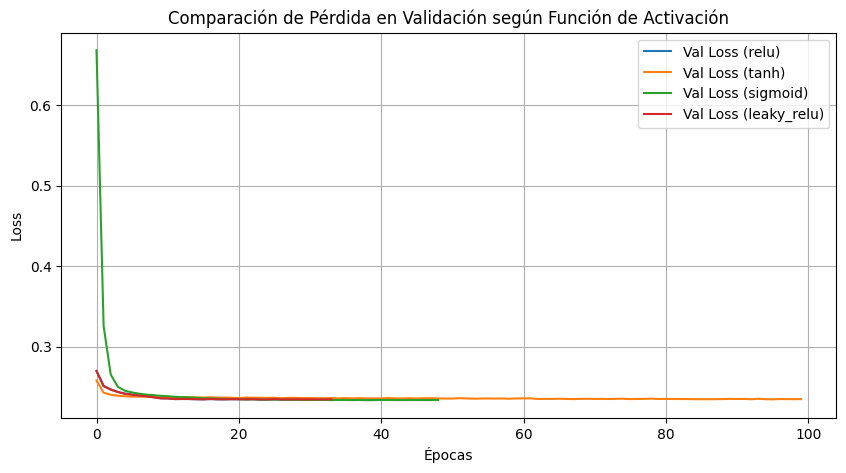


[TABLA COMPARATIVA DE ACTIVACIONES]:
Activación  Accuracy  Precision   Recall  F1-Score  Épocas  Brecha train-val
      relu  0.912867   0.912939 0.912867  0.912842      41         -0.001152
      tanh  0.914600   0.914661 0.914600  0.914586     100         -0.002957
   sigmoid  0.915200   0.915259 0.915200  0.915178      49         -0.006514
leaky_relu  0.913067   0.913191 0.913067  0.913036      34         -0.002567


In [ ]:
print("\n--- Evaluando Funciones de Activación ---")

def construir_modelo_activacion(activacion, capas=(64, 32)):
    inputs = layers.Input(shape=(X_train_scaled.shape[1],))
    x = inputs
    for neuronas in capas:
        if activacion == 'leaky_relu':
            x = layers.Dense(neuronas)(x)
            x = layers.LeakyReLU(negative_slope=0.01)(x)
        else:
            x = layers.Dense(neuronas, activation=activacion)(x)
        x = layers.Dropout(DROPOUT)(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    return keras.Model(inputs=inputs, outputs=outputs)

activaciones = ['relu', 'tanh', 'sigmoid', 'leaky_relu']
historias_act = {}
resultados_act = []

plt.figure(figsize=(10, 5))

for act in activaciones:
    fijar_semillas()
    modelo = construir_modelo_activacion(act)
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    hist = modelo.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=EPOCAS_MAX, batch_size=BATCH, callbacks=[early_stop()], verbose=0
    )

    historias_act[act] = hist

    # Evaluar en conjunto de validación
    y_pred_val = np.argmax(modelo.predict(X_val_scaled, verbose=0), axis=1)

    acc = accuracy_score(y_val, y_pred_val)
    prec = precision_score(y_val, y_pred_val, average='weighted')
    rec = recall_score(y_val, y_pred_val, average='weighted')
    f1 = f1_score(y_val, y_pred_val, average='weighted')

    resultados_act.append({
        'Activación': act,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Épocas': len(hist.history['loss']),
        'Brecha train-val': hist.history['accuracy'][-1] - acc
    })

    # Graficar Curva de Pérdida
    plt.plot(hist.history['val_loss'], label=f'Val Loss ({act})')

plt.title('Comparación de Pérdida en Validación según Función de Activación')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

df_act = pd.DataFrame(resultados_act)
print("\n[TABLA COMPARATIVA DE ACTIVACIONES]:")
print(df_act.to_string(index=False))

**Análisis:**

La diferencia de F1 entre la mejor activación (sigmoide, 0,9152) y la peor (ReLU, 0,9128) es de solo 0,0024. Con dos capas ocultas las cuatro funciones se comportan de forma muy parecida, porque el gradiente pasa por pocas derivadas de activación y la saturación de sigmoide y tanh no alcanza a notarse.

Donde sí vemos diferencias es en las épocas: LeakyReLU se detuvo en la 34 y ReLU en la 41, mientras que tanh usó las 100 épocas sin que se activara el Early Stopping. Las brechas negativas se deben al Dropout, porque la accuracy de entrenamiento se mide con el 20% de las neuronas apagadas.

Para ver si las diferencias aparecen al aumentar la profundidad, repetimos la comparación con una red más profunda en el Experimento 4.

**4. EXPERIMENTO 2:**

**Comparación Softmax + CrossEntropy vs Sigmoide/MSE (Pérdida Inadecuada)**

Para clasificación multiclase de etiqueta única empleamos la salida Softmax combinada con Categorical Cross-Entropy.
Softmax produce una distribución de probabilidad explícita para las 4 clases, mientras que Cross-Entropy aplica una penalización logarítmica severa a las predicciones incorrectas pero confiables.

Probamos también una combinación inadecuada, Sigmoide + MSE. La sigmoide calcula cada salida de forma independiente, así que las 4 salidas no están obligadas a sumar 1 y no representan una distribución de probabilidad sobre clases que son excluyentes. Como las pérdidas de Cross-Entropy y MSE tienen escalas distintas, no las comparamos en un mismo gráfico: comparamos la accuracy de validación, el F1 y la suma de las salidas.

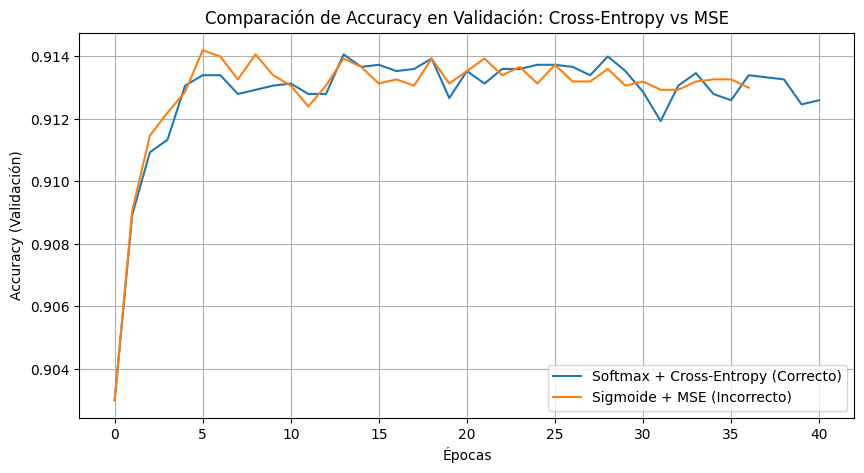

Softmax + Cross-Entropy   Accuracy: 0.9129 | F1-Score: 0.9128
Sigmoide + MSE            Accuracy: 0.9132 | F1-Score: 0.9132

Suma de las 4 salidas por muestra (debería ser 1):
Softmax + Cross-Entropy   media: 1.0000 | mín: 1.0000 | máx: 1.0000
Sigmoide + MSE            media: 0.9923 | mín: 0.8190 | máx: 1.4889


In [ ]:
# 1. Configuración Correcta: Softmax + Sparse Categorical Crossentropy
fijar_semillas()
mod_bueno = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'), layers.Dropout(DROPOUT),
    layers.Dense(32, activation='relu'), layers.Dropout(DROPOUT),
    layers.Dense(4, activation='softmax')
])
mod_bueno.compile(optimizer=keras.optimizers.Adam(LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_bueno = mod_bueno.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val),
                           epochs=EPOCAS_MAX, batch_size=BATCH, callbacks=[early_stop()], verbose=0)

# 2. Configuración Deficiente: Sigmoide + Mean Squared Error (MSE)
y_train_oh = keras.utils.to_categorical(y_train, 4)
y_val_oh = keras.utils.to_categorical(y_val, 4)

fijar_semillas()
mod_malo = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'), layers.Dropout(DROPOUT),
    layers.Dense(32, activation='relu'), layers.Dropout(DROPOUT),
    layers.Dense(4, activation='sigmoid')  # Mala elección para multiclase mutuamente excluyente
])
mod_malo.compile(optimizer=keras.optimizers.Adam(LR), loss='mean_squared_error', metrics=['accuracy'])
hist_malo = mod_malo.fit(X_train_scaled, y_train_oh, validation_data=(X_val_scaled, y_val_oh),
                         epochs=EPOCAS_MAX, batch_size=BATCH, callbacks=[early_stop()], verbose=0)

# Graficamos la accuracy de validación (las pérdidas CE y MSE tienen escalas distintas)
plt.figure(figsize=(10, 5))
plt.plot(hist_bueno.history['val_accuracy'], label='Softmax + Cross-Entropy (Correcto)')
plt.plot(hist_malo.history['val_accuracy'], label='Sigmoide + MSE (Incorrecto)')
plt.title('Comparación de Accuracy en Validación: Cross-Entropy vs MSE')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (Validación)')
plt.legend()
plt.grid(True)
plt.show()

# Métricas con el mismo criterio que los demás experimentos
for nombre, mod in [('Softmax + Cross-Entropy', mod_bueno), ('Sigmoide + MSE', mod_malo)]:
    y_p = np.argmax(mod.predict(X_val_scaled, verbose=0), axis=1)
    print(f"{nombre:25s} Accuracy: {accuracy_score(y_val, y_p):.4f} | F1-Score: {f1_score(y_val, y_p, average='weighted'):.4f}")

# ¿Las salidas forman una distribución de probabilidad?
print("\nSuma de las 4 salidas por muestra (debería ser 1):")
for nombre, mod in [('Softmax + Cross-Entropy', mod_bueno), ('Sigmoide + MSE', mod_malo)]:
    s = mod.predict(X_val_scaled, verbose=0).sum(axis=1)
    print(f"{nombre:25s} media: {s.mean():.4f} | mín: {s.min():.4f} | máx: {s.max():.4f}")

**Análisis:**

En accuracy las dos configuraciones quedan prácticamente iguales: F1 de 0,9128 con Softmax + Cross-Entropy y 0,9132 con Sigmoide + MSE, una diferencia de solo 0,0004. Esto ocurre porque al final el modelo elige la clase con la salida más alta en ambos casos.

La diferencia real está en lo que significan esas salidas. Con Softmax siempre suman exactamente 1, mientras que con Sigmoide la suma varía entre 0,819 y 1,489. Eso quiere decir que un registro podría recibir valores altos en dos categorías a la vez, o valores bajos en todas, lo que no tiene sentido si cada material pertenece a una sola categoría.

Por eso elegimos Softmax + Sparse Categorical Crossentropy: no porque tenga mejor accuracy, sino porque es la combinación que corresponde a un problema multiclase con clases excluyentes y entrega probabilidades que se pueden interpretar.

**5. EXPERIMENTO 3:**

**Comparación de Tamaños de Arquitectura (Capas y Neuronas)**

Evaluamos configuraciones de 1 a 3 capas y una red ancha para analizar la relación entre la capacidad del modelo y la velocidad de entrenamiento. Incrementar el número de parámetros solo se justifica si aporta una ganancia significativa en el F1-Score en validación; de lo contrario, agregar neuronas/capas solo incrementa el tiempo de cómputo y el riesgo de sobreajuste.


--- Evaluando Tamaños de Arquitectura ---

[TABLA COMPARATIVA DE ARQUITECTURAS]:
    Configuración  Parámetros Totales  Accuracy Val  Precision Val  Recall Val  F1-Score Val  Épocas  Brecha train-val
        1_capa_64                1732      0.913067       0.913118    0.913067      0.913041      37          0.000276
    2_capas_64_32                3684      0.912867       0.912939    0.912867      0.912842      41         -0.001152
3_capas_128_64_32               13412      0.913733       0.913822    0.913733      0.913726      30         -0.000762
    ancha_256_128               39300      0.913467       0.913573    0.913467      0.913484      17          0.001190


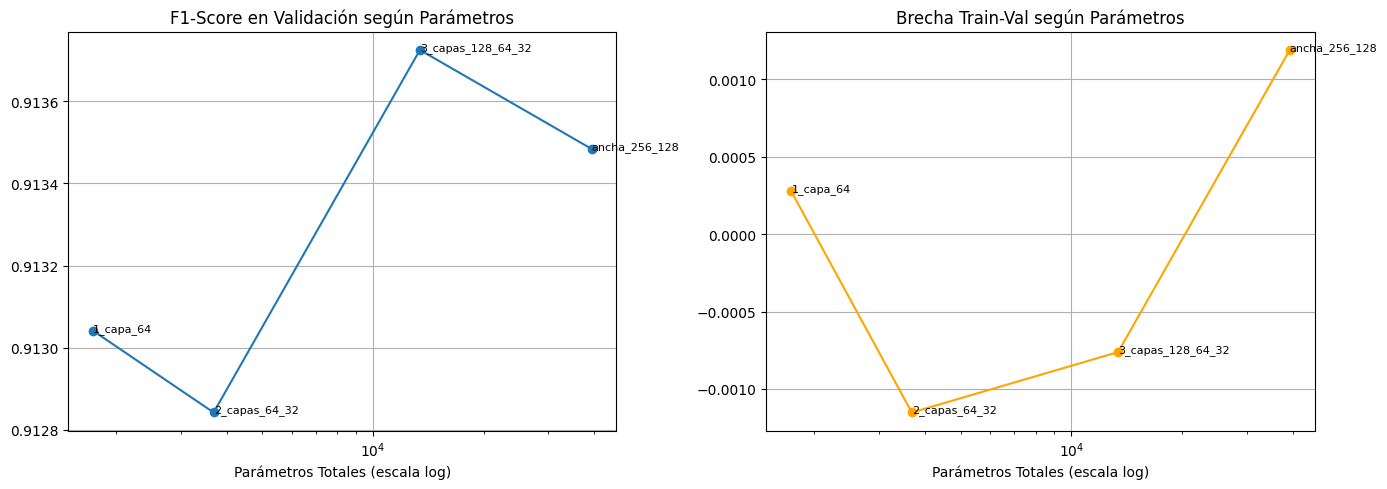

In [ ]:
print("\n--- Evaluando Tamaños de Arquitectura ---")

def crear_arquitectura(opcion):
    capas = {
        '1_capa_64': [64],
        '2_capas_64_32': [64, 32],
        '3_capas_128_64_32': [128, 64, 32],
        'ancha_256_128': [256, 128],
    }[opcion]
    inputs = layers.Input(shape=(X_train_scaled.shape[1],))
    x = inputs
    for neuronas in capas:
        x = layers.Dense(neuronas, activation='relu')(x)
        x = layers.Dropout(DROPOUT)(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    return keras.Model(inputs=inputs, outputs=outputs)

opciones_arq = ['1_capa_64', '2_capas_64_32', '3_capas_128_64_32', 'ancha_256_128']
resultados_arq = []

for op in opciones_arq:
    fijar_semillas()
    m = crear_arquitectura(op)
    m.compile(optimizer=keras.optimizers.Adam(LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Contar parámetros entrenables
    params = m.count_params()

    h = m.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val),
              epochs=EPOCAS_MAX, batch_size=BATCH, callbacks=[early_stop()], verbose=0)

    y_pred_v = np.argmax(m.predict(X_val_scaled, verbose=0), axis=1)
    acc_v = accuracy_score(y_val, y_pred_v)

    resultados_arq.append({
        'Configuración': op,
        'Parámetros Totales': params,
        'Accuracy Val': acc_v,
        'Precision Val': precision_score(y_val, y_pred_v, average='weighted'),
        'Recall Val': recall_score(y_val, y_pred_v, average='weighted'),
        'F1-Score Val': f1_score(y_val, y_pred_v, average='weighted'),
        'Épocas': len(h.history['loss']),
        'Brecha train-val': h.history['accuracy'][-1] - acc_v
    })

df_arq = pd.DataFrame(resultados_arq)
print("\n[TABLA COMPARATIVA DE ARQUITECTURAS]:")
print(df_arq.to_string(index=False))

# Gráfico: F1 y brecha según la cantidad de parámetros
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(df_arq['Parámetros Totales'], df_arq['F1-Score Val'], 'o-')
ax[1].plot(df_arq['Parámetros Totales'], df_arq['Brecha train-val'], 'o-', color='orange')
for i, op in enumerate(df_arq['Configuración']):
    ax[0].annotate(op, (df_arq['Parámetros Totales'][i], df_arq['F1-Score Val'][i]), fontsize=8)
    ax[1].annotate(op, (df_arq['Parámetros Totales'][i], df_arq['Brecha train-val'][i]), fontsize=8)
ax[0].set_title('F1-Score en Validación según Parámetros')
ax[1].set_title('Brecha Train-Val según Parámetros')
for a in ax:
    a.set_xscale('log')
    a.set_xlabel('Parámetros Totales (escala log)')
    a.grid(True)
plt.tight_layout()
plt.show()

**Análisis:**

Al aumentar la cantidad de parámetros de 1.732 a 39.300 (unas 22 veces más), el F1 prácticamente no cambia: va desde 0,9128 (2 capas) hasta 0,9137 (3 capas), una diferencia de solo 0,0009. La brecha entre entrenamiento y validación también se mantiene mínima en todas, entre −0,0012 y +0,0012.

Esto muestra que, con Dropout y Early Stopping, agregar capacidad no provoca sobreajuste, pero tampoco mejora el modelo: el problema no necesita una red más grande. La red ancha, además, se detuvo en solo 17 épocas, lo que indica que alcanza rápido su mejor punto y después deja de aprender.

Mantenemos la arquitectura de 2 capas (64 y 32), porque ninguna otra la supera en más de 0,005 de F1 y los hiperparámetros del notebook principal se ajustaron sobre esta misma arquitectura. La red de 3 capas tiene 3,6 veces más parámetros para ganar apenas 0,0009, lo que no justifica el cambio.

**6. EXPERIMENTO 4:**

**Efecto de la Profundidad en las Funciones de Activación**

En el Experimento 1 las cuatro activaciones dieron resultados casi iguales con 2 capas. Para comprobar si el desvanecimiento del gradiente aparece al hacer la red más profunda, repetimos la comparación con 5 capas ocultas (128-64-64-32-16).

Además medimos cuánto gradiente llega a cada capa antes de entrenar. La derivada de la sigmoide nunca supera 0,25, así que en cada capa el gradiente se reduce al menos a un cuarto. Si esto pasa, las primeras capas reciben un gradiente muy pequeño y aprenden mucho más lento.


--- Evaluando Activaciones en una Red Profunda ---

[GRADIENTE PROMEDIO POR CAPA ANTES DE ENTRENAR]:
             relu     tanh  sigmoid
Oculta 1 1.69e-03 1.12e-02 1.58e-05
Oculta 2 1.11e-03 7.27e-03 2.75e-05
Oculta 3 1.24e-03 8.72e-03 1.30e-04
Oculta 4 1.59e-03 1.25e-02 8.40e-04
Oculta 5 2.09e-03 1.53e-02 4.78e-03
Salida   4.97e-03 3.58e-02 3.09e-02
relu: el gradiente en la salida es 2.9 veces el de la primera capa
tanh: el gradiente en la salida es 3.2 veces el de la primera capa
sigmoid: el gradiente en la salida es 1959.1 veces el de la primera capa


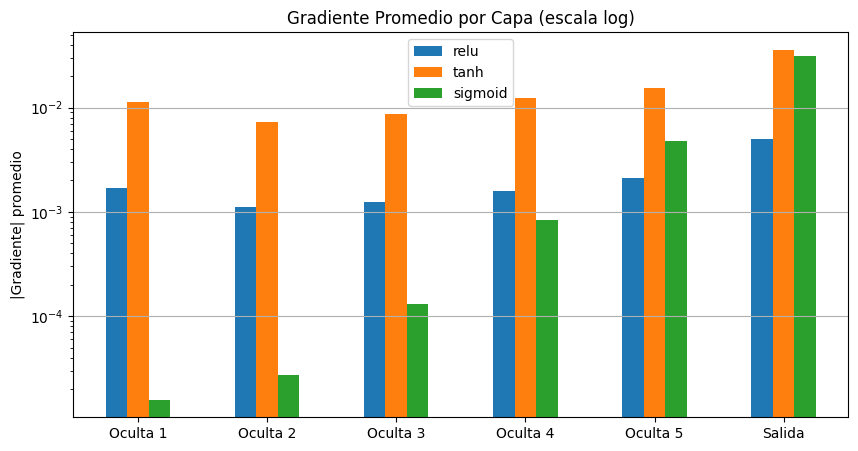

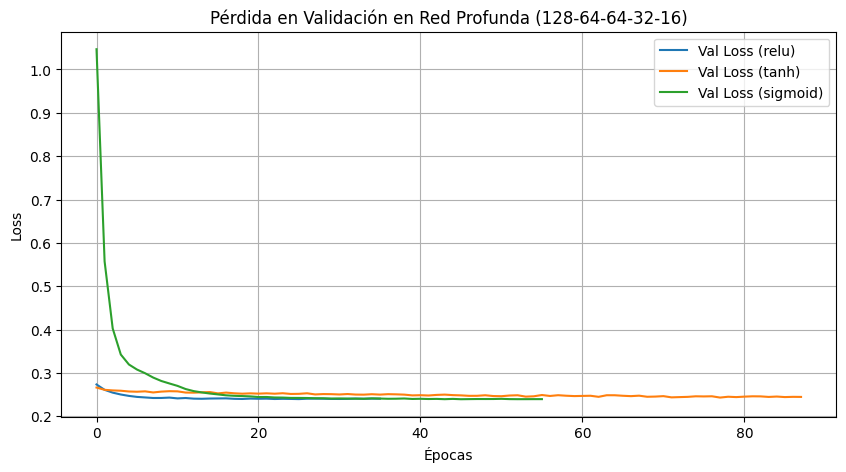


[TABLA RED PROFUNDA]:
Activación  F1-Score  Val Loss mínima  Épocas
      relu  0.913813         0.239818      36
      tanh  0.913903         0.243327      88
   sigmoid  0.913931         0.239528      56


In [ ]:
print("\n--- Evaluando Activaciones en una Red Profunda ---")

capas_profundas = (128, 64, 64, 32, 16)
acts_profundas = ['relu', 'tanh', 'sigmoid']

# 1. Gradiente que llega a cada capa antes de entrenar
def gradiente_por_capa(activacion):
    fijar_semillas()
    m = construir_modelo_activacion(activacion, capas=capas_profundas)
    xb = X_train_scaled[:2048]
    yb = y_train.values[:2048]
    with tf.GradientTape() as tape:
        loss = keras.losses.SparseCategoricalCrossentropy()(yb, m(xb, training=False))
    grads = tape.gradient(loss, m.trainable_variables)
    # Solo matrices de pesos (se excluyen los bias)
    return [float(tf.reduce_mean(tf.abs(g))) for g, v in zip(grads, m.trainable_variables) if len(v.shape) == 2]

nombres_capas = ['Oculta 1', 'Oculta 2', 'Oculta 3', 'Oculta 4', 'Oculta 5', 'Salida']
df_grad = pd.DataFrame({act: gradiente_por_capa(act) for act in acts_profundas}, index=nombres_capas)

print("\n[GRADIENTE PROMEDIO POR CAPA ANTES DE ENTRENAR]:")
print(df_grad.to_string(float_format='{:.2e}'.format))
for act in acts_profundas:
    print(f"{act}: el gradiente en la salida es {df_grad[act].iloc[-1] / df_grad[act].iloc[0]:.1f} veces el de la primera capa")

df_grad.plot(kind='bar', logy=True, figsize=(10, 5))
plt.title('Gradiente Promedio por Capa (escala log)')
plt.ylabel('|Gradiente| promedio')
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.show()

# 2. Entrenamiento completo de la red profunda
resultados_prof = []
plt.figure(figsize=(10, 5))
for act in acts_profundas:
    fijar_semillas()
    modelo = construir_modelo_activacion(act, capas=capas_profundas)
    modelo.compile(optimizer=keras.optimizers.Adam(LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist = modelo.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val),
                      epochs=EPOCAS_MAX, batch_size=BATCH, callbacks=[early_stop()], verbose=0)
    y_pred_val = np.argmax(modelo.predict(X_val_scaled, verbose=0), axis=1)
    resultados_prof.append({
        'Activación': act,
        'F1-Score': f1_score(y_val, y_pred_val, average='weighted'),
        'Val Loss mínima': min(hist.history['val_loss']),
        'Épocas': len(hist.history['loss'])
    })
    plt.plot(hist.history['val_loss'], label=f'Val Loss ({act})')

plt.title('Pérdida en Validación en Red Profunda (128-64-64-32-16)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("\n[TABLA RED PROFUNDA]:")
print(pd.DataFrame(resultados_prof).to_string(index=False))

**Análisis:**

Con la sigmoide, el gradiente que llega a la primera capa es 1.959 veces menor que el de la capa de salida, mientras que con ReLU es solo 2,9 veces menor y con tanh 3,2 veces. Esto confirma el desvanecimiento del gradiente: como la derivada de la sigmoide es como máximo 0,25, al multiplicarse capa tras capa el gradiente se hace muy pequeño antes de llegar a las primeras capas.

Sin embargo, al entrenar la red profunda las tres activaciones llegan al mismo F1 (0,9138 con ReLU, 0,9139 con tanh y 0,9139 con sigmoide). Esto se explica porque usamos Adam, que ajusta el tamaño del paso de cada parámetro según la magnitud de sus gradientes: cuando un gradiente es muy pequeño, Adam lo compensa dando un paso relativamente más grande. Por eso la sigmoide igual logra aprender.

Donde sí se nota el desvanecimiento es en la velocidad: ReLU alcanza su mejor punto y se detiene en 36 épocas, la sigmoide necesita 56 (un 56% más) y tanh 88.

Por eso elegimos ReLU para las capas ocultas: en la red de 2 capas todas rinden igual, y en la red profunda ReLU converge más rápido porque no depende del optimizador para compensar un gradiente que se desvanece.

**7. EXPERIMENTO 5:**

**Evaluación del Modelo Final en el Conjunto de Prueba**

### Justificación del Modelo Seleccionado

A partir de nuestros experimentos y de los del notebook principal, la configuración final es:

* **Arquitectura:** 2 capas ocultas de **64 y 32 neuronas** (Experimento 3). Las redes más grandes no mejoraron el F1 y aumentaron la brecha entre entrenamiento y validación.
* **Activación:** **ReLU** en las capas ocultas (Experimentos 1 y 4). Todas las activaciones obtienen un F1 similar, pero ReLU no sufre desvanecimiento del gradiente y converge en menos épocas al aumentar la profundidad.
* **Salida y pérdida:** **Softmax + Sparse Categorical Crossentropy** (Experimento 2), porque genera una distribución de probabilidad válida sobre las 4 categorías.
* **Entrenamiento:** Adam con learning rate 0.0005, batch size 256, Dropout 0.2 y Early Stopping con paciencia 10 (experimentos B1 a B5 del notebook principal).

---

### Aislamiento del Conjunto de Prueba (*Test Set*)

El conjunto `X_test_scaled` (15% del total) permaneció completamente aislado durante todos los experimentos. Evaluamos sobre él una sola vez, con el modelo final entrenado en el notebook principal (cargando sus pesos desde `modelo_final_pesos.npz`, lo que evita problemas de compatibilidad entre versiones de Keras)

In [ ]:
print("\nEvaluación Final en Conjunto de Prueba Desconocido (X_test_scaled) ---")

rutas_pesos = ['modelo_final_pesos.npz', '../notebook/modelo_final_pesos.npz']
encontradas = [r for r in rutas_pesos if os.path.exists(r)]

fijar_semillas()
modelo_final = construir_modelo_activacion('relu', capas=(64, 32))

if encontradas:
    pesos = np.load(encontradas[0])
    modelo_final.set_weights([pesos[f'arr_{i}'] for i in range(len(pesos.files))])
    print("Pesos del modelo final cargados desde:", encontradas[0])
else:
    print("No se encontraron los pesos: entrenamos el modelo final con la configuración seleccionada.")
    modelo_final.compile(optimizer=keras.optimizers.Adam(LR),
                         loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    modelo_final.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val),
                     epochs=EPOCAS_MAX, batch_size=BATCH, callbacks=[early_stop()], verbose=0)

y_pred_probs_test = modelo_final.predict(X_test_scaled, verbose=0)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_pred_val_final = np.argmax(modelo_final.predict(X_val_scaled, verbose=0), axis=1)

# Cálculo de métricas requeridas
acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, average='weighted')
rec_test = recall_score(y_test, y_pred_test, average='weighted')
f1_test = f1_score(y_test, y_pred_test, average='weighted')
f1_val = f1_score(y_val, y_pred_val_final, average='weighted')

print("\n" + "="*60)
print(" CUADRO RESUMEN DE MÉTRICAS FINALES (TEST SET - MODELO FINAL)")
print("="*60)
print(f" Accuracy  : {acc_test:.4f}")
print(f" Precision : {prec_test:.4f} (Weighted)")
print(f" Recall    : {rec_test:.4f} (Weighted)")
print(f" F1-Score  : {f1_test:.4f} (Weighted)")
print("-"*60)
print(f" F1-Score en validación: {f1_val:.4f} | Diferencia test - val: {f1_test - f1_val:+.4f}")
print("="*60 + "\n")

# Desglose de desempeño por cada categoría curricular
nombres_categorias = [
    '0: NÚMEROS Y OPERACIONES',
    '1: ÁLGEBRA Y FUNCIONES',
    '2: GEOMETRÍA Y MEDICIÓN',
    '3: DATOS Y PROBABILIDAD'
]

print("Reporte de Clasificación Detallado por Categoría:")
print(classification_report(y_test, y_pred_test, target_names=nombres_categorias, digits=4))


Evaluación Final en Conjunto de Prueba Desconocido (X_test_scaled) ---
Pesos del modelo final cargados desde: modelo_final_pesos.npz

 CUADRO RESUMEN DE MÉTRICAS FINALES (TEST SET - MODELO FINAL)
 Accuracy  : 0.9108
 Precision : 0.9108 (Weighted)
 Recall    : 0.9108 (Weighted)
 F1-Score  : 0.9108 (Weighted)
------------------------------------------------------------
 F1-Score en validación: 0.9132 | Diferencia test - val: -0.0025

Reporte de Clasificación Detallado por Categoría:
                          precision    recall  f1-score   support

0: NÚMEROS Y OPERACIONES     0.9094    0.9007    0.9050      4533
  1: ÁLGEBRA Y FUNCIONES     0.9091    0.9150    0.9120      4045
 2: GEOMETRÍA Y MEDICIÓN     0.9120    0.9078    0.9099      3460
 3: DATOS Y PROBABILIDAD     0.9139    0.9240    0.9189      2962

                accuracy                         0.9108     15000
               macro avg     0.9111    0.9119    0.9115     15000
            weighted avg     0.9108    0.9108    

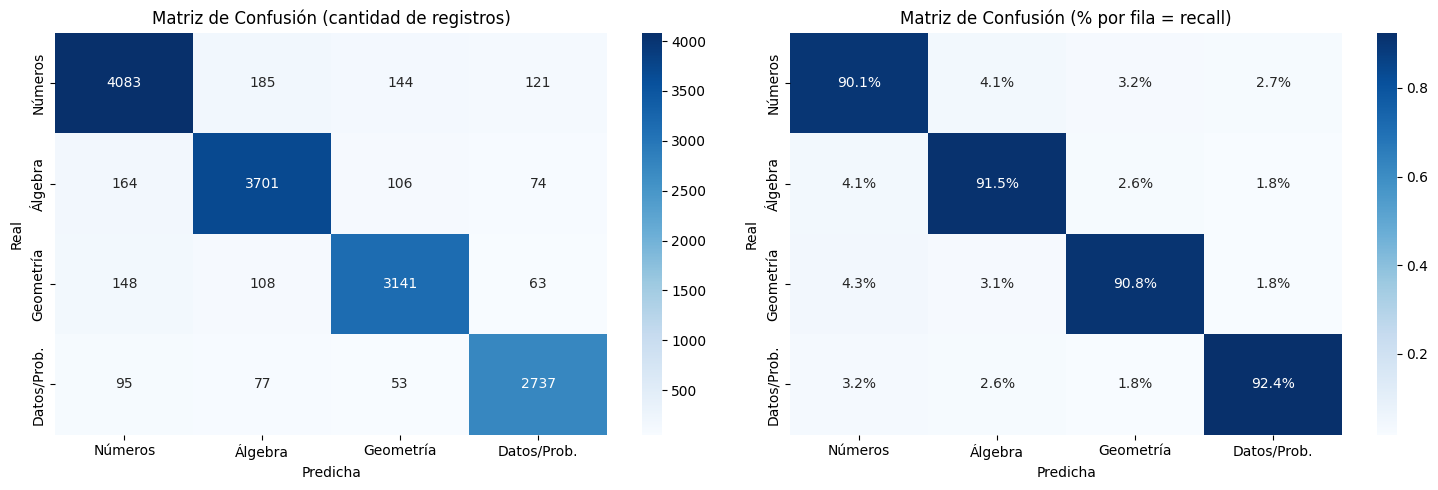

In [ ]:
# Matriz de confusión: filas = categoría real, columnas = categoría predicha
cm = confusion_matrix(y_test, y_pred_test)
etiquetas_cortas = ['Números', 'Álgebra', 'Geometría', 'Datos/Prob.']

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=etiquetas_cortas, yticklabels=etiquetas_cortas)
ax[0].set_title('Matriz de Confusión (cantidad de registros)')
ax[0].set_xlabel('Predicha'); ax[0].set_ylabel('Real')

sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt='.1%', cmap='Blues', ax=ax[1],
            xticklabels=etiquetas_cortas, yticklabels=etiquetas_cortas)
ax[1].set_title('Matriz de Confusión (% por fila = recall)')
ax[1].set_xlabel('Predicha'); ax[1].set_ylabel('Real')
plt.tight_layout()
plt.show()

In [ ]:
# Calculamos precision, recall y F1 a mano desde la matriz de confusión
# VP = diagonal | FP = resto de la columna | FN = resto de la fila
print("[CÁLCULO MANUAL DE MÉTRICAS POR CATEGORÍA]:\n")

etiquetas_cortas = ['Números', 'Álgebra', 'Geometría', 'Datos/Prob.']
cm = confusion_matrix(y_test, y_pred_test)

f1_por_clase, soportes = [], []
for k, nombre in enumerate(etiquetas_cortas):
    vp = cm[k, k]
    fp = cm[:, k].sum() - vp
    fn = cm[k, :].sum() - vp
    precision = vp / (vp + fp)
    recall = vp / (vp + fn)
    f1_k = 2 * precision * recall / (precision + recall)
    f1_por_clase.append(f1_k)
    soportes.append(cm[k, :].sum())
    print(f"{nombre}: VP={vp}, FP={fp}, FN={fn}")
    print(f"   Precision = {vp}/({vp}+{fp}) = {precision:.4f}")
    print(f"   Recall    = {vp}/({vp}+{fn}) = {recall:.4f}")
    print(f"   F1        = 2*P*R/(P+R) = {f1_k:.4f}\n")

f1_ponderado = np.average(f1_por_clase, weights=soportes)
print(f"Accuracy = {np.trace(cm)}/{cm.sum()} = {np.trace(cm)/cm.sum():.4f}")
print(f"F1 ponderado (manual) = {f1_ponderado:.4f} | F1 de sklearn = {f1_test:.4f}")

errores = sorted([(etiquetas_cortas[r], etiquetas_cortas[p], cm[r, p])
                  for r in range(4) for p in range(4) if r != p], key=lambda e: -e[2])
print("Confusiones más frecuentes:")
for real, pred, n in errores[:3]:
    print(f"  {n} registros de {real} clasificados como {pred}")

[CÁLCULO MANUAL DE MÉTRICAS POR CATEGORÍA]:

Números: VP=4083, FP=407, FN=450
   Precision = 4083/(4083+407) = 0.9094
   Recall    = 4083/(4083+450) = 0.9007
   F1        = 2*P*R/(P+R) = 0.9050

Álgebra: VP=3701, FP=370, FN=344
   Precision = 3701/(3701+370) = 0.9091
   Recall    = 3701/(3701+344) = 0.9150
   F1        = 2*P*R/(P+R) = 0.9120

Geometría: VP=3141, FP=303, FN=319
   Precision = 3141/(3141+303) = 0.9120
   Recall    = 3141/(3141+319) = 0.9078
   F1        = 2*P*R/(P+R) = 0.9099

Datos/Prob.: VP=2737, FP=258, FN=225
   Precision = 2737/(2737+258) = 0.9139
   Recall    = 2737/(2737+225) = 0.9240
   F1        = 2*P*R/(P+R) = 0.9189

Accuracy = 13662/15000 = 0.9108
F1 ponderado (manual) = 0.9108 | F1 de sklearn = 0.9108
Confusiones más frecuentes:
  185 registros de Números clasificados como Álgebra
  164 registros de Álgebra clasificados como Números
  148 registros de Geometría clasificados como Números


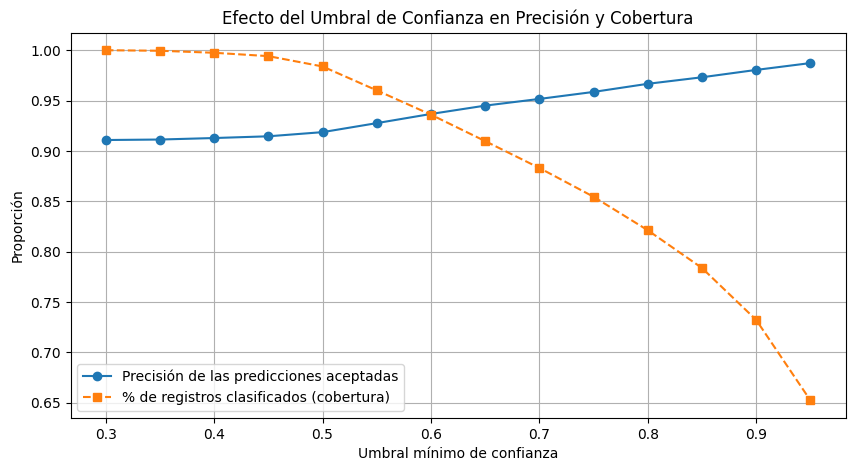

 Umbral  Precisión  Cobertura
   0.30     0.9108     1.0000
   0.35     0.9113     0.9995
   0.40     0.9128     0.9975
   0.45     0.9145     0.9941
   0.50     0.9186     0.9839
   0.55     0.9276     0.9601
   0.60     0.9367     0.9360
   0.65     0.9450     0.9097
   0.70     0.9516     0.8831
   0.75     0.9586     0.8545
   0.80     0.9666     0.8212
   0.85     0.9731     0.7837
   0.90     0.9804     0.7322
   0.95     0.9872     0.6523


In [ ]:
# Si solo aceptamos las predicciones en que el modelo está más seguro,
# la precisión sube pero quedan registros sin clasificar
confianza = y_pred_probs_test.max(axis=1)
umbrales = np.arange(0.3, 0.96, 0.05)
precisiones, coberturas = [], []
for u in umbrales:
    aceptadas = confianza >= u
    coberturas.append(aceptadas.mean())
    precisiones.append((y_pred_test[aceptadas] == np.array(y_test)[aceptadas]).mean())

plt.figure(figsize=(10, 5))
plt.plot(umbrales, precisiones, 'o-', label='Precisión de las predicciones aceptadas')
plt.plot(umbrales, coberturas, 's--', label='% de registros clasificados (cobertura)')
plt.title('Efecto del Umbral de Confianza en Precisión y Cobertura')
plt.xlabel('Umbral mínimo de confianza')
plt.ylabel('Proporción')
plt.legend()
plt.grid(True)
plt.show()

print(pd.DataFrame({'Umbral': umbrales, 'Precisión': precisiones, 'Cobertura': coberturas}).round(4).to_string(index=False))

**Análisis:**

El modelo final obtiene un F1 de 0,9108 en test, frente a 0,9132 en validación. Como la diferencia es de solo 0,0025, confirmamos que las decisiones que tomamos con validación no quedaron sobreajustadas a ese conjunto.

Por categoría, la mejor es Datos y Probabilidad (F1 0,9189) y la más difícil es Números y Operaciones (F1 0,9050). Llama la atención que la categoría con menos registros sea la que mejor se clasifica y la que tiene más registros sea la peor: el desempeño no depende de la cantidad de datos, sino de qué tan distintas son las características de cada categoría. Números tiene el recall más bajo (0,9007): de sus 4.533 registros, el modelo no detecta 450. El error más frecuente es clasificar Números como Álgebra (185 registros), y la confusión inversa, Álgebra como Números, es la segunda más frecuente (164). En conjunto suman 349 registros, lo que indica que estas dos categorías comparten características en el dataset, como la presencia de operaciones aritméticas en ambos tipos de contenido. Además, Números aparece en las tres confusiones principales, lo que explica que sea la categoría con menor recall: de sus 450 errores, el 41% corresponde a registros clasificados como Álgebra.

Para mejorar precision y recall proponemos:
* **Umbral de confianza:** si solo aceptamos predicciones con confianza mayor a 0,80, la precisión sube de 0,9108 a 0,9666, clasificando automáticamente el 82,1% de los registros. El 17,9% restante podría revisarse manualmente. Con un umbral de 0,60 se logra un punto intermedio: precisión de 0,9367 cubriendo el 93,6%.
* **Pesos por clase (`class_weight`):** no parecen prioritarios en este caso, porque la categoría con menos registros ya es la de mejor desempeño. Serían útiles, en cambio, para darle más peso a Números y subir su recall.
* **Nuevas variables** que ayuden a diferenciar Números de Álgebra, que son las categorías que más se confunden entre sí. Por ejemplo, indicadores que distingan operaciones con valores numéricos concretos de expresiones con variables.